# Stage 2 — Understanding Visual and Temporal Data

This notebook creates a small Flappy Bird-style game, then turns sequences of rendered frames into visual and temporal observations for a CNN.

In [32]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path('02_intro_to_flappy_bird').resolve()))
from flappy_bird_environment import FlappyBirdEnv

# initialise flappy bird environment
env = FlappyBirdEnv(seed=7)
# flappy bird at starting position
frame, info = env.reset(seed=7)
# 84 x 84 image with 3 channels (RGB)
# no pipes passed at starting position
print('action space:', env.action_space)
print('frame shape:', frame.shape)
print('reset info:', info)

action space: Discrete(2)
frame shape: (84, 84, 3)
reset info: {'pipes_passed': 0}


## 1. Game actions and rewards

Action `0` does nothing. Action `1` flaps upward. The agent receives a small survival reward, a larger pipe-passing reward, and a terminal penalty after a collision.

step result: (84, 84, 3) 0.08500000000000002 False False {'pipes_passed': 0}


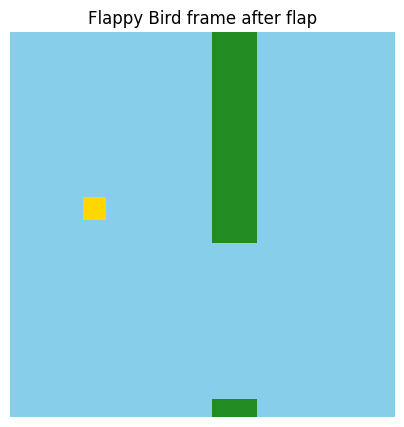

In [33]:
# flap upwards
# reward = 0, terminated = False, truncated = False, info = {}
next_frame, reward, terminated, truncated, info = env.step(1)
print('step result:', next_frame.shape, reward, terminated, truncated, info)

plt.figure(figsize=(5, 5))
plt.imshow(next_frame)
plt.axis('off')
plt.title('Flappy Bird frame after flap')
plt.show()

step result: (84, 84, 3) 0.0 False False {'pipes_passed': 0}


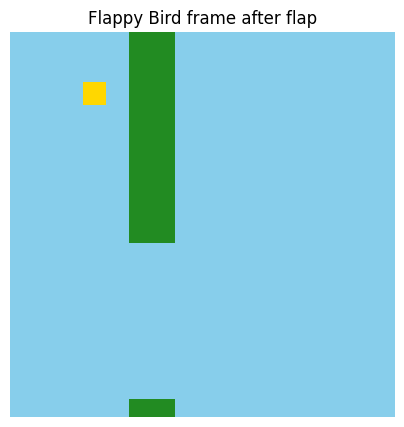

In [34]:
# after flapping upwards 8 times
# flappy bird seems higher than the starting position
for _ in range(8):
    next_frame, reward, terminated, truncated, info = env.step(1)
print('step result:', next_frame.shape, reward, terminated, truncated, info)

plt.figure(figsize=(5, 5))
plt.imshow(next_frame)
plt.axis('off')
plt.title('Flappy Bird frame after flap')
plt.show()

## 2. Preprocess the screenshot

Convert RGB to grayscale and downsample by two. Four frames are concatenated along the channel dimension so the CNN can infer motion.

processed shape: (42, 42)
processed values: 1764


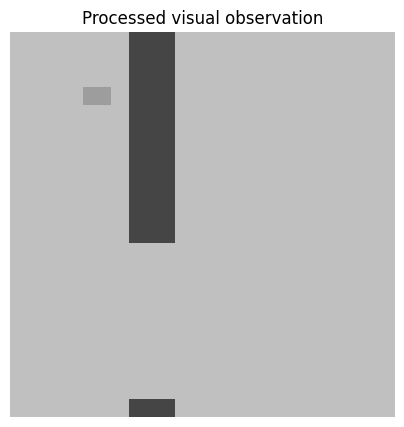

In [35]:
# taking the mean across the color channels (axis=2) 
# normalizing the pixel values to the range [0, 1]. 
# downsample the image by taking every second pixel in both dimensions.
def preprocess(frame):
    grayscale = frame.mean(axis=2).astype(np.float32) / 255.0
    return grayscale[::2, ::2]

processed = preprocess(next_frame)
print('processed shape:', processed.shape)
print('processed values:', processed.size)

plt.figure(figsize=(5, 5))
plt.imshow(processed, cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('Processed visual observation')
plt.show()

### Checkpoint — numerical shape

The CNN receives four grayscale frames with shape `(4, 42, 42)`, which contains `4 × 42 × 42 = 7,056` values.

In [36]:
# as expected
frame_stack = np.stack([processed] * 4)
print('four-frame stack:', frame_stack.shape)
assert frame_stack.shape == (4, 42, 42)
assert frame_stack.min() >= 0.0 and frame_stack.max() <= 1.0
print('Stage 2 Flappy Bird visual checks passed.')

four-frame stack: (4, 42, 42)
Stage 2 Flappy Bird visual checks passed.
